# PokeTeammates — Analyse des données Pokémon

## Problématique
**Comment exploiter les données issues de l'API Pokémon afin de concevoir, de manière objective, la meilleure équipe possible en fonction des performances globales et la complémentarité stratégique des Pokémon ?**

---

### Plan d'analyse
1. Chargement et nettoyage des données
2. Statistiques descriptives
3. Distribution des types
4. Analyse des statistiques de combat
5. Efficacités de types (offensif & défensif, mono & dual)
6. Construction d'équipe optimale multi-critères

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ast
from collections import Counter
from math import pi

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')
print('Librairies chargées')

Librairies chargées


---
## 1. Chargement & Nettoyage des données

In [92]:
df = pd.read_csv('pokemon_data.csv')

df['types']        = df['types'].apply(ast.literal_eval)
df['abilities']    = df['abilities'].apply(ast.literal_eval)
df['moves']        = df['moves'].apply(ast.literal_eval)
df['game_indices'] = df['game_indices'].apply(ast.literal_eval)
df['stats']        = df['stats'].apply(ast.literal_eval)

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
for stat in STATS:
    df[stat] = df['stats'].apply(lambda s: s.get(stat, np.nan))

df['bst']     = df[STATS].sum(axis=1)
df['type1']   = df['types'].apply(lambda t: t[0] if len(t) > 0 else None)
df['type2']   = df['types'].apply(lambda t: t[1] if len(t) > 1 else None)
df['n_types'] = df['types'].apply(len)
df['n_moves'] = df['moves'].apply(len)

n_before = len(df)
df.drop_duplicates(subset='id', inplace=True)
df.dropna(subset=['name', 'type1'] + STATS, inplace=True)
df.reset_index(drop=True, inplace=True)

df.head(3)

,id,name,types,abilities,moves,stats,game_indices,generation,hp,attack,defense,special-attack,special-defense,speed,bst,type1,type2,n_types,n_moves
0,1,bulbasaur,"[grass, poison]","[overgrow, chlorophyll]","[razor-wind, swords-dance, cut, bind, vine-whi...","{'hp': 45, 'attack': 49, 'defense': 49, 'speci...","[red, blue, yellow, gold, silver, crystal, rub...",generation-i,45,49,49,65,65,45,318,grass,poison,2,86
1,2,ivysaur,"[grass, poison]","[overgrow, chlorophyll]","[swords-dance, cut, bind, vine-whip, headbutt,...","{'hp': 60, 'attack': 62, 'defense': 63, 'speci...","[red, blue, yellow, gold, silver, crystal, rub...",generation-i,60,62,63,80,80,60,405,grass,poison,2,83
2,3,venusaur,"[grass, poison]","[overgrow, chlorophyll]","[swords-dance, cut, bind, vine-whip, headbutt,...","{'hp': 80, 'attack': 82, 'defense': 83, 'speci...","[red, blue, yellow, gold, silver, crystal, rub...",generation-i,80,82,83,100,100,80,525,grass,poison,2,96


---
## 2. Statistiques descriptives

In [93]:
stat_labels = {'hp': 'HP', 'attack': 'Attaque', 'defense': 'Défense',
               'special-attack': 'Attaque Spé.', 'special-defense': 'Défense Spé.', 'speed': 'Vitesse'}

print('Statistiques descriptives')
display(df[STATS + ['bst']].describe().round(2))

print('\nMono-type vs Dual-type')
print(df['n_types'].value_counts().rename({1: 'Mono-type', 2: 'Dual-type'}))

Statistiques descriptives


,hp,attack,defense,special-attack,special-defense,speed,bst
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,70.18,77.52,72.51,70.08,70.21,67.19,427.69
std,26.63,29.78,29.29,29.66,26.64,28.72,112.77
min,1.00,5.00,5.00,10.00,20.00,5.00,175.00
25%,50.00,55.00,50.00,47.00,50.00,45.00,325.00
50%,68.00,75.00,70.00,65.00,67.00,65.00,450.00
75%,85.00,100.00,90.00,90.00,86.00,88.00,508.00
max,255.00,181.00,230.00,173.00,230.00,200.00,720.00



Mono-type vs Dual-type
n_types
Dual-type    526
Mono-type    499
Name: count, dtype: int64


---
## 3. Distribution des types

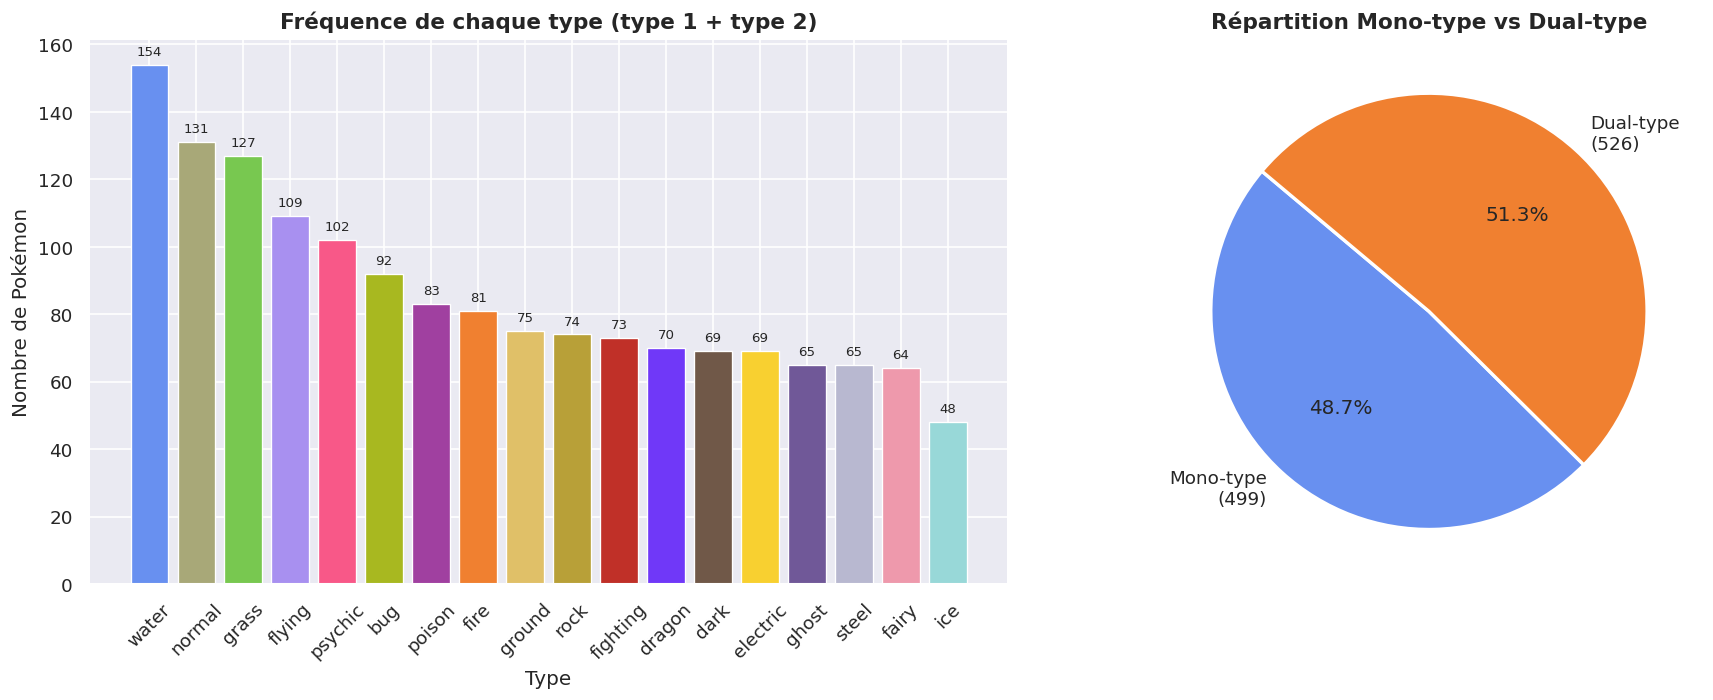

In [94]:
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC',
}

all_types = [t for types in df['types'] for t in types]
type_counts = pd.Series(Counter(all_types)).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = [TYPE_COLORS.get(t, '#888') for t in type_counts.index]
bars = axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Fréquence de chaque type (type 1 + type 2)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Nombre de Pokémon')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                 ha='center', va='bottom', fontsize=8)

mono = (df['n_types'] == 1).sum()
dual = (df['n_types'] == 2).sum()
axes[1].pie([mono, dual], labels=[f'Mono-type\n({mono})', f'Dual-type\n({dual})'],
            autopct='%1.1f%%', colors=['#6890F0', '#F08030'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition Mono-type vs Dual-type', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Analyse des statistiques de combat

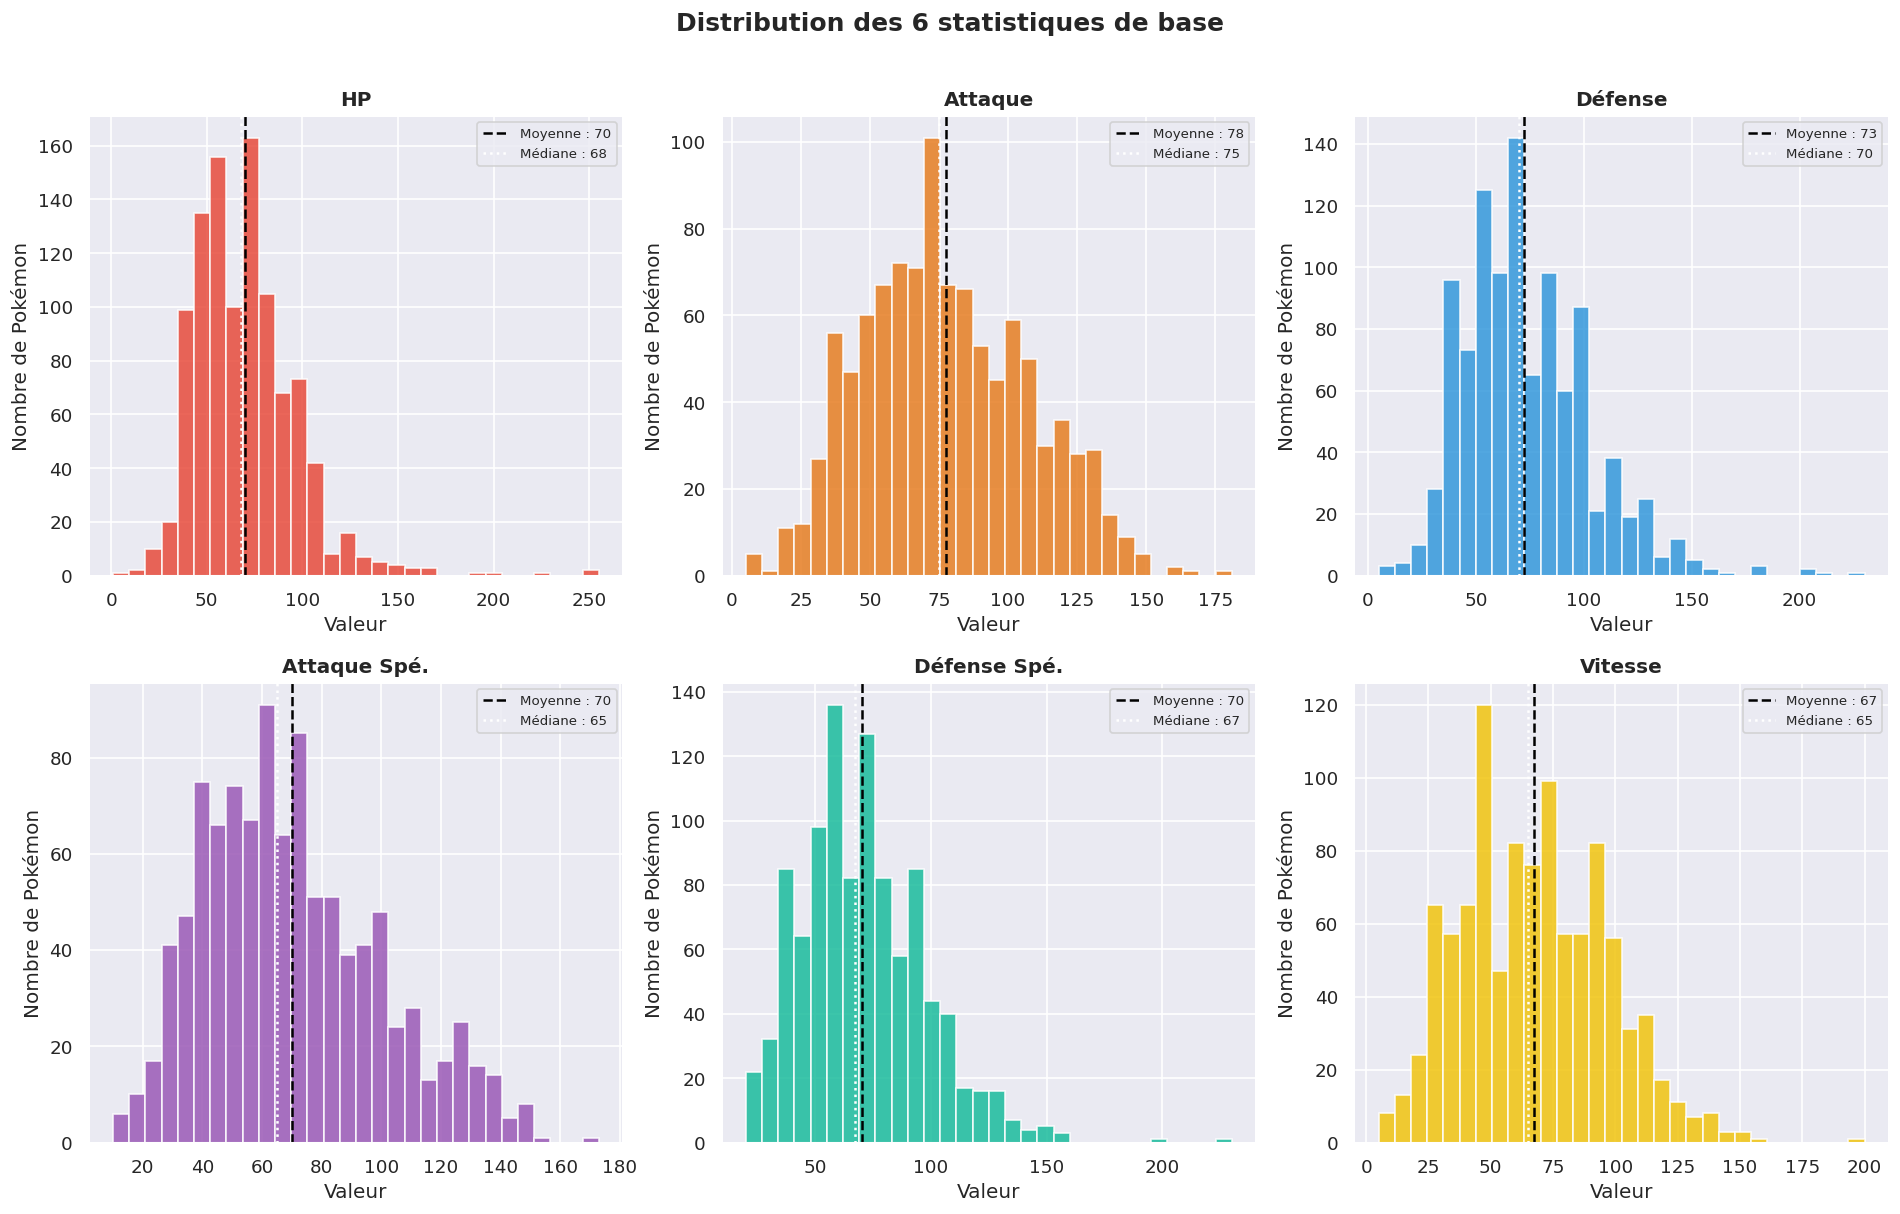

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors_stats = ['#E74C3C', '#E67E22', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F']

for ax, stat, color in zip(axes, STATS, colors_stats):
    data = df[stat].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Moyenne : {data.mean():.0f}')
    ax.axvline(data.median(), color='white', linestyle=':',  linewidth=1.5, label=f'Médiane : {data.median():.0f}')
    ax.set_title(stat_labels[stat], fontsize=12, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Nombre de Pokémon')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des 6 statistiques de base', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Efficacités de types (offensif & défensif, mono & dual)

> **Défense dual-type** : multiplicateur reçu = produit des deux types (ex: Water/Flying vs Electric → 2×2 = **4×**)  
> **Offense dual-type** : un Pokémon peut attaquer avec les deux types → l'union de leurs couvertures offensives (STAB)

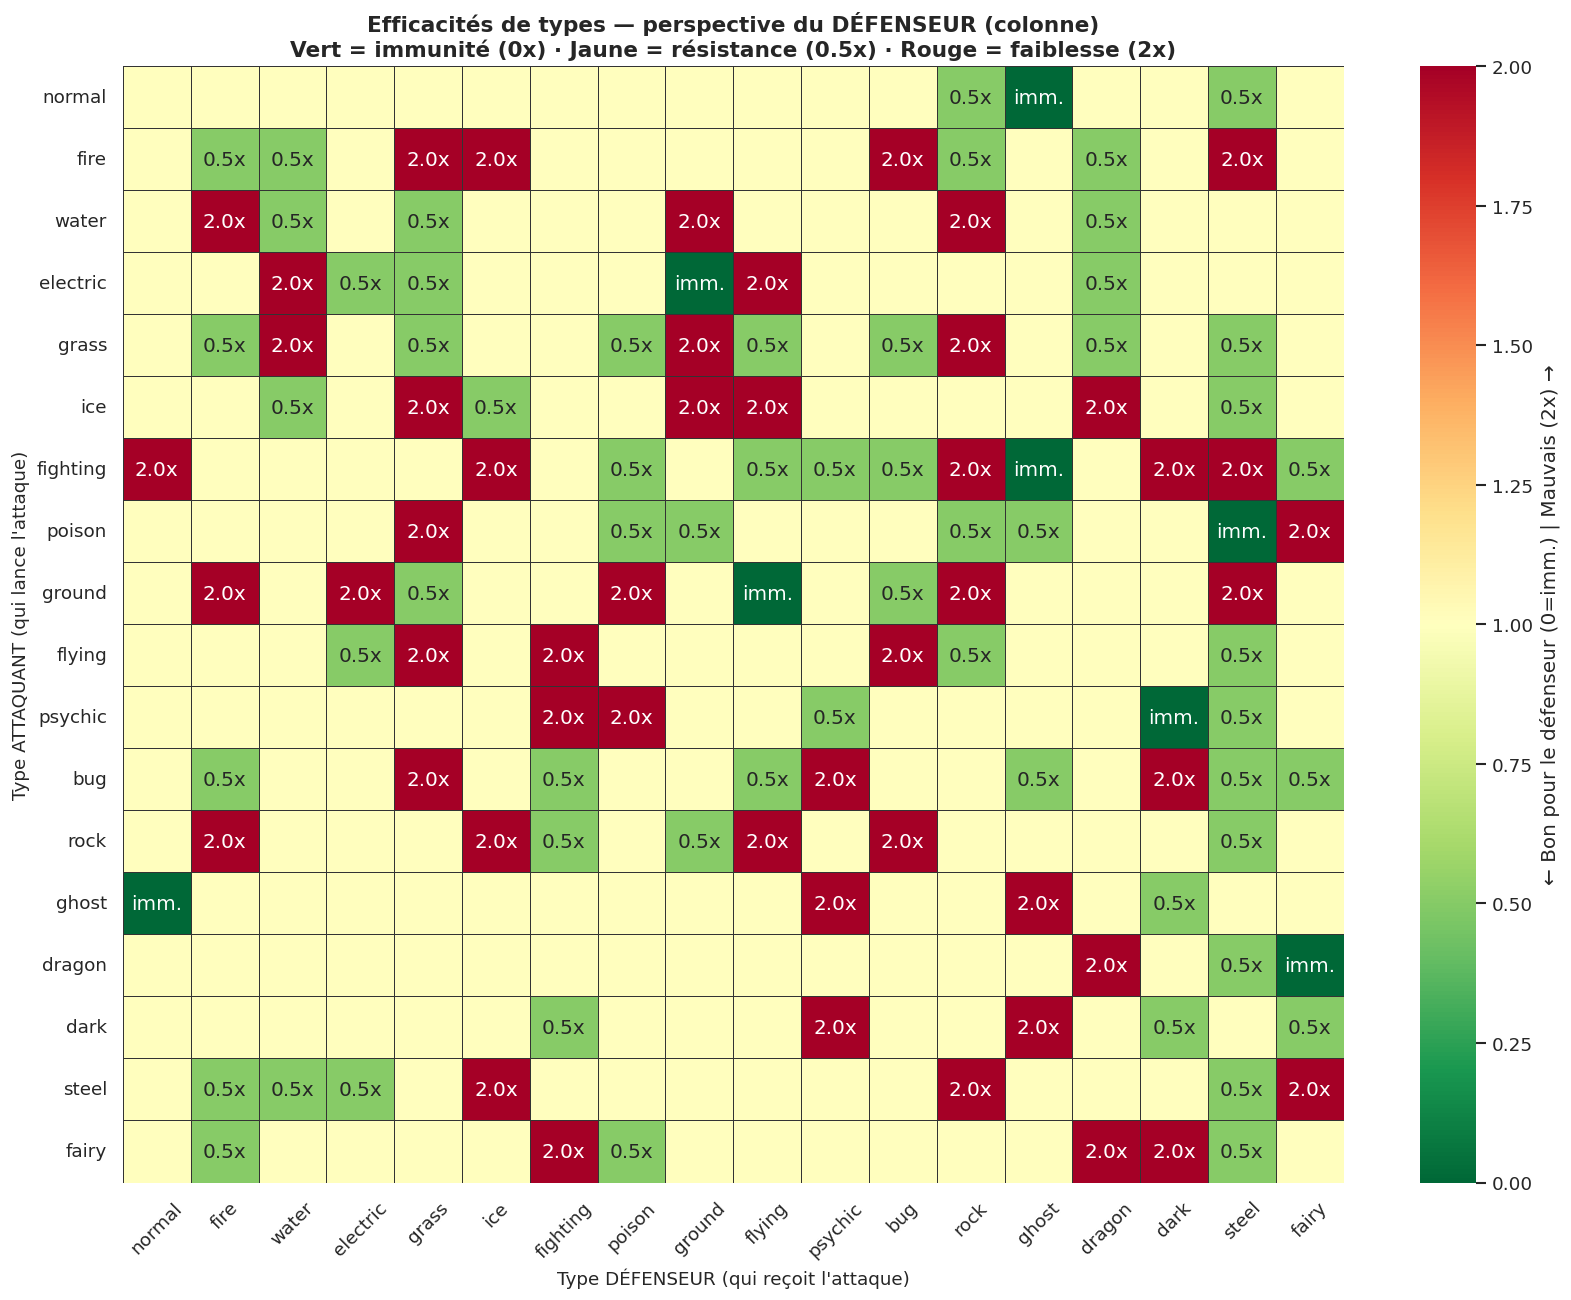

In [96]:
TYPE_CHART = {
    'normal':   {'rock': 0.5, 'ghost': 0, 'steel': 0.5},
    'fire':     {'fire': 0.5, 'water': 0.5, 'grass': 2, 'ice': 2, 'bug': 2, 'rock': 0.5, 'dragon': 0.5, 'steel': 2},
    'water':    {'fire': 2, 'water': 0.5, 'grass': 0.5, 'ground': 2, 'rock': 2, 'dragon': 0.5},
    'electric': {'water': 2, 'electric': 0.5, 'grass': 0.5, 'ground': 0, 'flying': 2, 'dragon': 0.5},
    'grass':    {'fire': 0.5, 'water': 2, 'grass': 0.5, 'poison': 0.5, 'ground': 2, 'flying': 0.5, 'bug': 0.5, 'rock': 2, 'dragon': 0.5, 'steel': 0.5},
    'ice':      {'water': 0.5, 'grass': 2, 'ice': 0.5, 'ground': 2, 'flying': 2, 'dragon': 2, 'steel': 0.5},
    'fighting': {'normal': 2, 'ice': 2, 'poison': 0.5, 'flying': 0.5, 'psychic': 0.5, 'bug': 0.5, 'rock': 2, 'ghost': 0, 'dark': 2, 'steel': 2, 'fairy': 0.5},
    'poison':   {'grass': 2, 'poison': 0.5, 'ground': 0.5, 'rock': 0.5, 'ghost': 0.5, 'steel': 0, 'fairy': 2},
    'ground':   {'fire': 2, 'electric': 2, 'grass': 0.5, 'poison': 2, 'flying': 0, 'bug': 0.5, 'rock': 2, 'steel': 2},
    'flying':   {'electric': 0.5, 'grass': 2, 'fighting': 2, 'bug': 2, 'rock': 0.5, 'steel': 0.5},
    'psychic':  {'fighting': 2, 'poison': 2, 'psychic': 0.5, 'dark': 0, 'steel': 0.5},
    'bug':      {'fire': 0.5, 'grass': 2, 'fighting': 0.5, 'flying': 0.5, 'psychic': 2, 'ghost': 0.5, 'dark': 2, 'steel': 0.5, 'fairy': 0.5},
    'rock':     {'fire': 2, 'ice': 2, 'fighting': 0.5, 'ground': 0.5, 'flying': 2, 'bug': 2, 'steel': 0.5},
    'ghost':    {'normal': 0, 'psychic': 2, 'ghost': 2, 'dark': 0.5},
    'dragon':   {'dragon': 2, 'steel': 0.5, 'fairy': 0},
    'dark':     {'fighting': 0.5, 'psychic': 2, 'ghost': 2, 'dark': 0.5, 'fairy': 0.5},
    'steel':    {'fire': 0.5, 'water': 0.5, 'electric': 0.5, 'ice': 2, 'rock': 2, 'steel': 0.5, 'fairy': 2},
    'fairy':    {'fire': 0.5, 'fighting': 2, 'poison': 0.5, 'dragon': 2, 'dark': 2, 'steel': 0.5},
}
ALL_TYPES = list(TYPE_CHART.keys())

matrix = pd.DataFrame(1.0, index=ALL_TYPES, columns=ALL_TYPES)
for att, defenses in TYPE_CHART.items():
    for defe, mult in defenses.items():
        matrix.loc[att, defe] = mult

def defense_profile(types):
    return {att: np.prod([matrix.loc[att, t] for t in types if t in matrix.columns])
            for att in ALL_TYPES}

def offensive_coverage(types):
    covered = set()
    for att in types: 
        if att in matrix.index:
            covered.update(t for t in ALL_TYPES if matrix.loc[att, t] == 2)
    return covered

df['defense_profile']  = df['types'].apply(defense_profile)
df['offense_coverage'] = df['types'].apply(offensive_coverage)
df['n_weaknesses']     = df['defense_profile'].apply(lambda p: sum(1 for v in p.values() if v > 1))
df['n_resistances']    = df['defense_profile'].apply(lambda p: sum(1 for v in p.values() if 0 < v < 1))
df['n_immunities']     = df['defense_profile'].apply(lambda p: sum(1 for v in p.values() if v == 0))
df['n_offense']        = df['offense_coverage'].apply(len)
df['defense_score']    = df['n_resistances'] + 2*df['n_immunities'] - df['n_weaknesses']

fig, ax = plt.subplots(figsize=(14, 11))
annot = matrix.map(lambda v: '' if v == 1.0 else ('imm.' if v == 0 else f'{v}x'))
sns.heatmap(
    matrix,
    annot=annot, fmt='',
    cmap='RdYlGn_r', 
    center=1, vmin=0, vmax=2,
    linewidths=0.4, linecolor='#333', ax=ax,
    cbar_kws={'label': '← Bon pour le défenseur (0=imm.) | Mauvais (2x) →'}
)
ax.set_title(
    'Efficacités de types — perspective du DÉFENSEUR (colonne)\n'
    'Vert = immunité (0x) · Jaune = résistance (0.5x) · Rouge = faiblesse (2x)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Type DÉFENSEUR (qui reçoit l\'attaque)', fontsize=11)
ax.set_ylabel('Type ATTAQUANT (qui lance l\'attaque)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

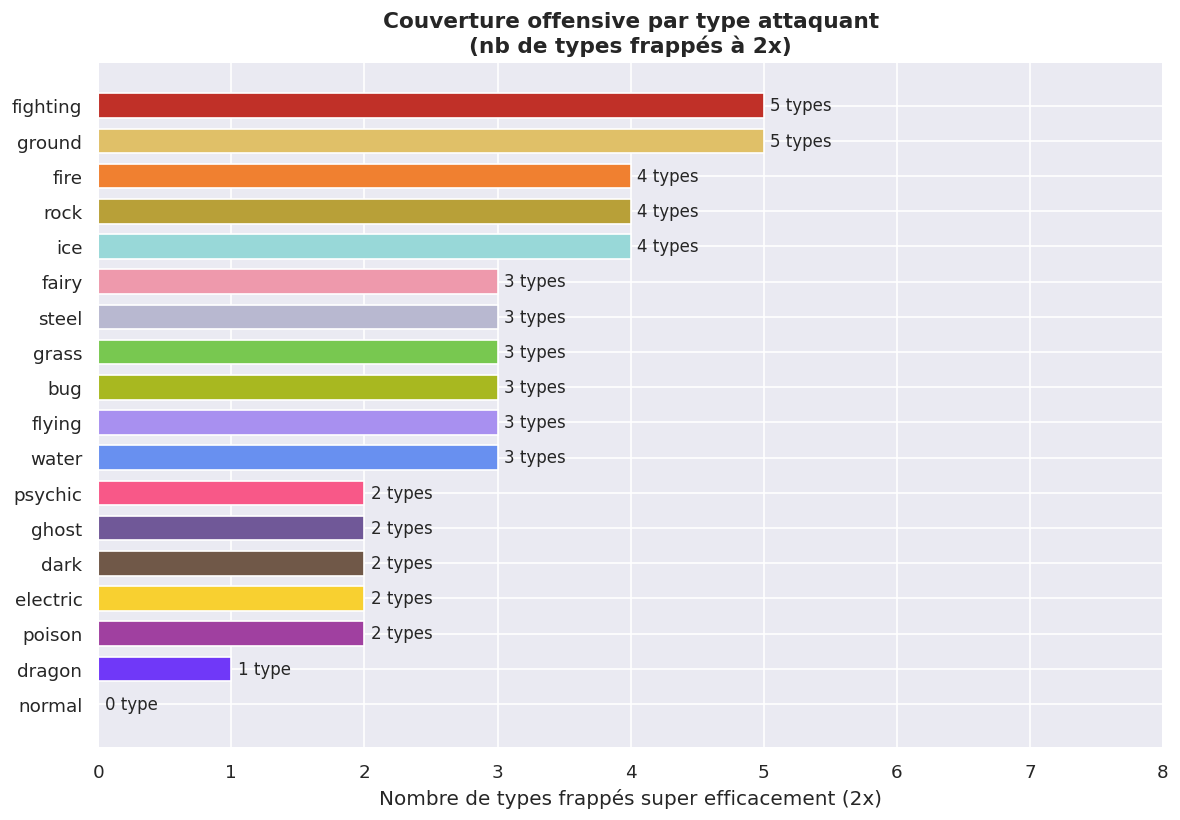

In [97]:
off_count = {t: int((matrix.loc[t] == 2).sum()) for t in ALL_TYPES}
off_series = pd.Series(off_count).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [TYPE_COLORS.get(t, '#888') for t in off_series.index]
bars = ax.barh(off_series.index, off_series.values, color=bar_colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, off_series.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val} type{"s" if val > 1 else ""}', va='center', fontsize=10)
ax.set_title('Couverture offensive par type attaquant\n(nb de types frappés à 2x)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre de types frappés super efficacement (2x)')
ax.set_xlim(0, max(off_series) + 3)
plt.tight_layout()
plt.show()


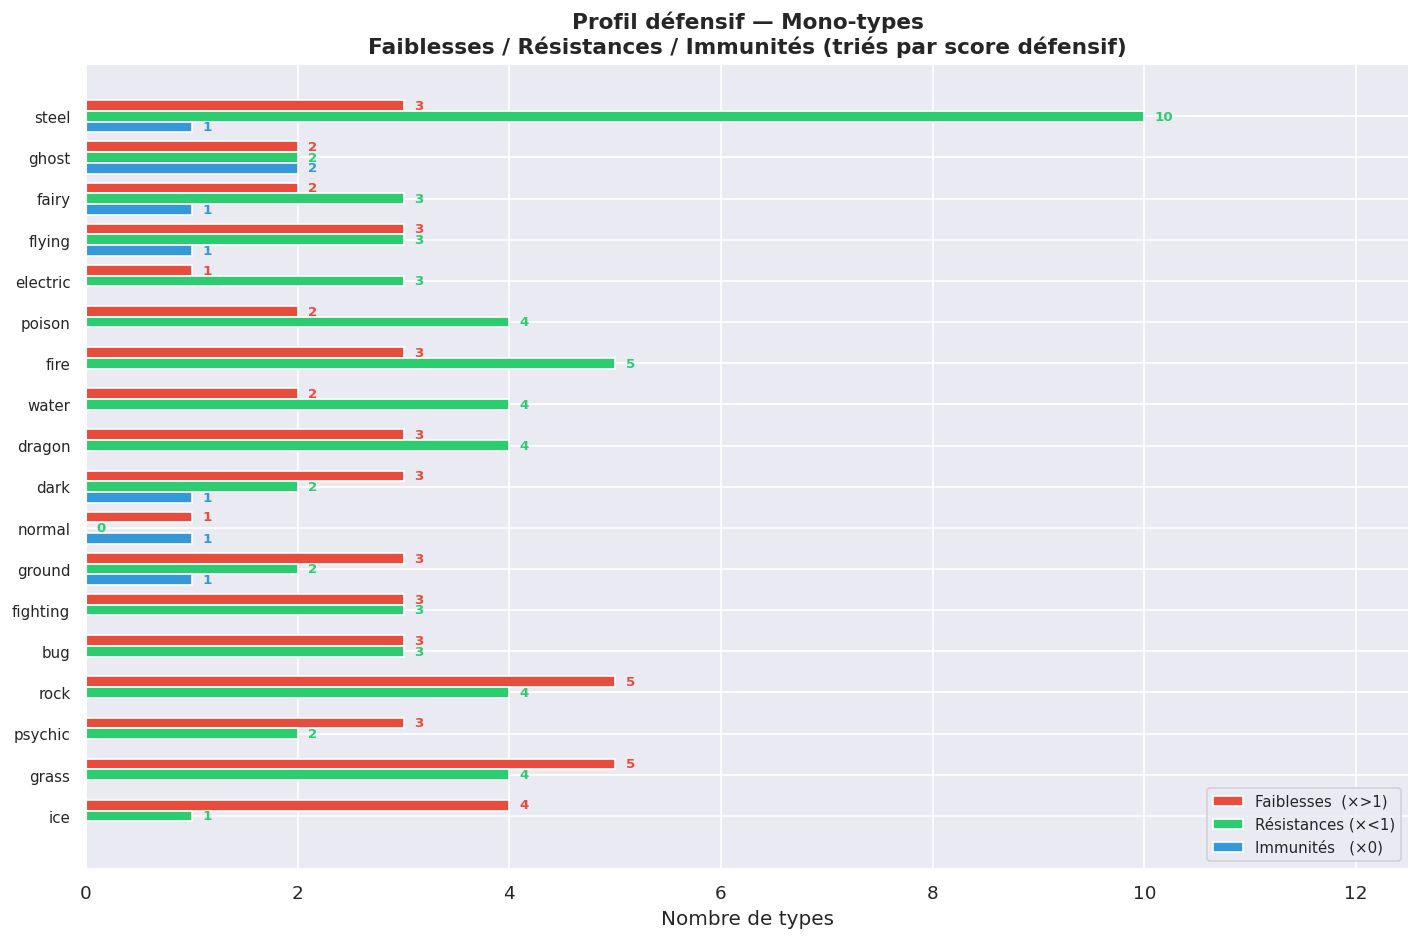

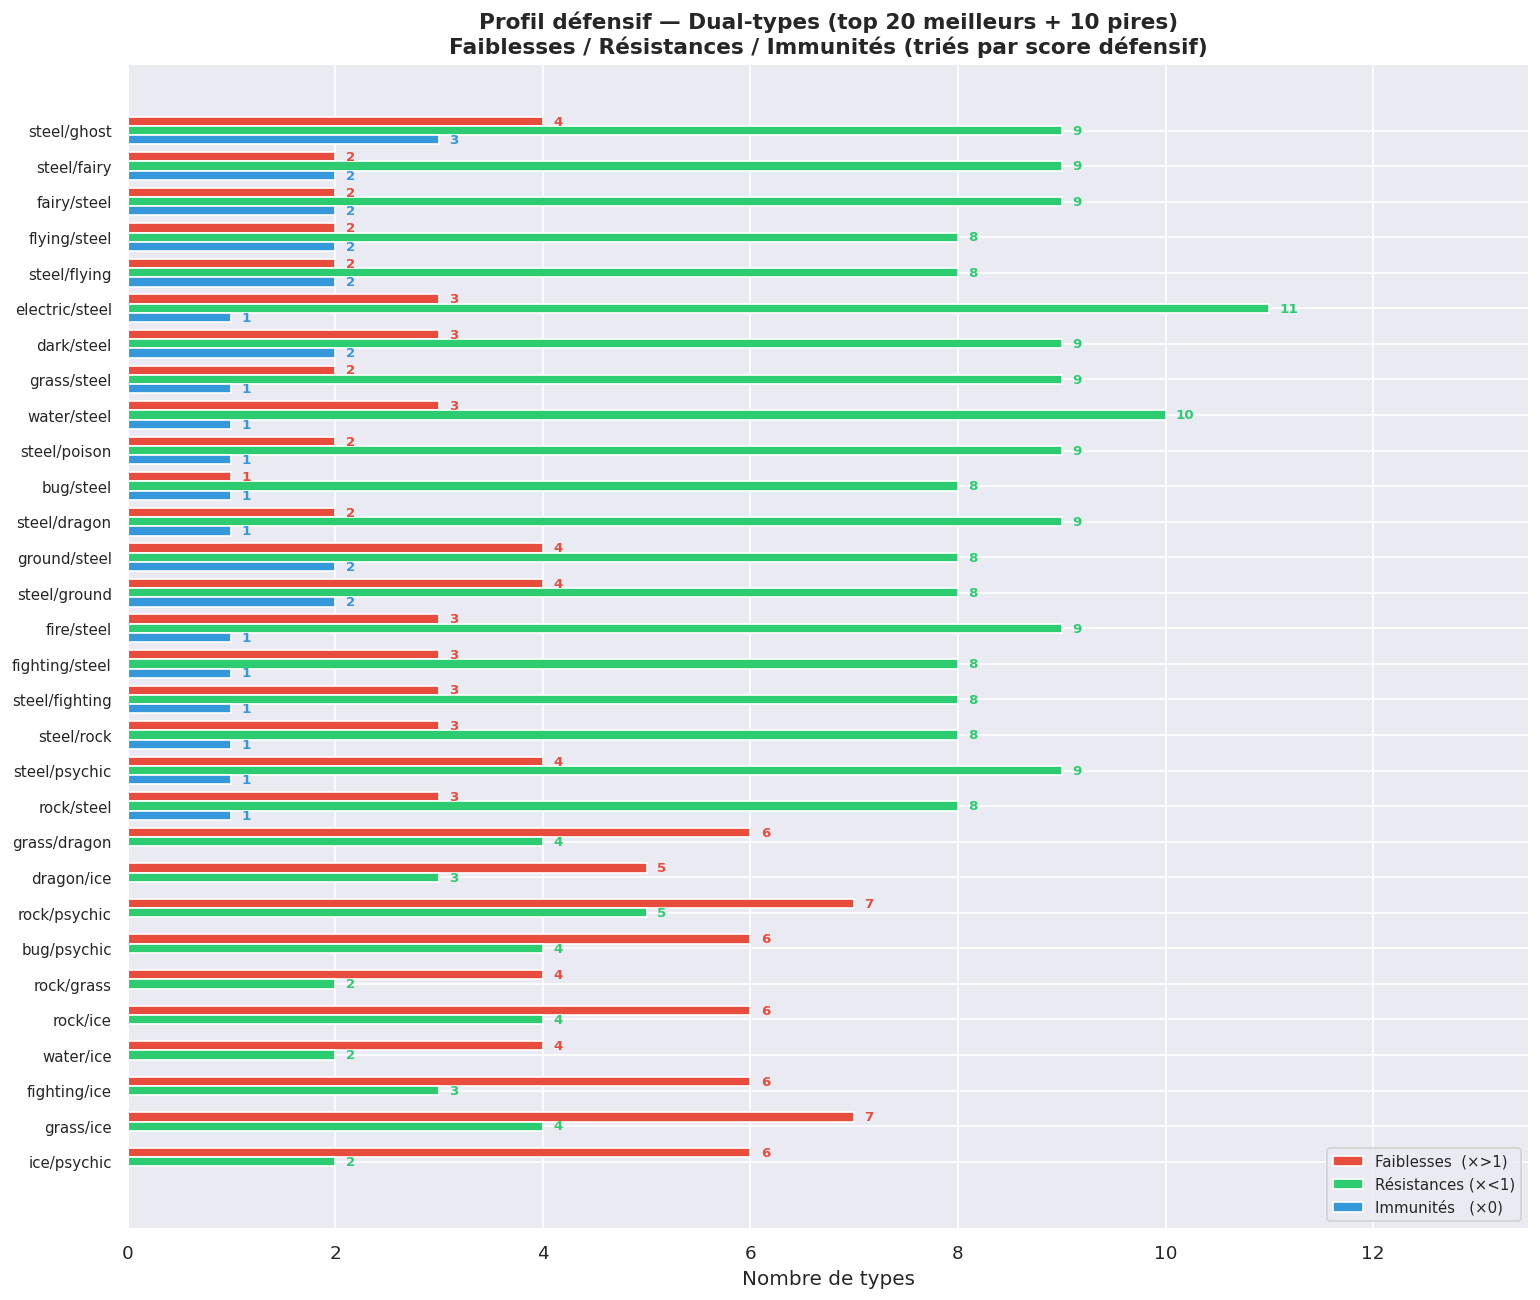


Top 10 meilleures combinaisons défensives


,label,n_weaknesses,n_resistances,n_immunities,defense_score
0,steel/fairy,2,9,2,11
1,fairy/steel,2,9,2,11
2,steel/ghost,4,9,3,11
3,dark/steel,3,9,2,10
4,flying/steel,2,8,2,10
5,electric/steel,3,11,1,10
6,steel/flying,2,8,2,10
7,bug/steel,1,8,1,9
8,water/steel,3,10,1,9
9,grass/steel,2,9,1,9


In [98]:
type_combos = df[['type1', 'type2']].drop_duplicates().reset_index(drop=True)

records = []
for _, row in type_combos.iterrows():
    types   = [row['type1']] if pd.isna(row['type2']) else [row['type1'], row['type2']]
    label   = row['type1'] if pd.isna(row['type2']) else f"{row['type1']}/{row['type2']}"
    is_dual = not pd.isna(row['type2'])
    profile = {att: float(np.prod([matrix.loc[att, t] for t in types if t in matrix.columns]))
               for att in ALL_TYPES}
    n_weak = sum(1 for v in profile.values() if v > 1)
    n_res  = sum(1 for v in profile.values() if 0 < v < 1)
    n_imm  = sum(1 for v in profile.values() if v == 0)
    covered = set()
    for att in types:
        if att in matrix.index:
            covered.update(t for t in ALL_TYPES if matrix.loc[att, t] == 2)
    records.append({
        'label': label, 'type1': row['type1'], 'is_dual': is_dual,
        'n_weaknesses': n_weak, 'n_resistances': n_res, 'n_immunities': n_imm,
        'defense_score': n_res + 2*n_imm - n_weak,
        'n_offense': len(covered), 'offense_coverage': covered,
    })

combo_df = pd.DataFrame(records)
mono_df  = combo_df[~combo_df['is_dual']].sort_values('defense_score', ascending=True).reset_index(drop=True)
dual_df  = combo_df[combo_df['is_dual']].sort_values('defense_score', ascending=False)
top_dual = pd.concat([dual_df.head(20), dual_df.tail(10)]).drop_duplicates(subset=['label']).sort_values('defense_score', ascending=True).reset_index(drop=True)

def grouped_barh(ax, data, title):
    y  = np.arange(len(data))
    h  = 0.26
    ax.barh(y + h, data['n_weaknesses'],  h, color='#E74C3C', edgecolor='white', label='Faiblesses  (×>1)')
    ax.barh(y,     data['n_resistances'], h, color='#2ECC71', edgecolor='white', label='Résistances (×<1)')
    ax.barh(y - h, data['n_immunities'],  h, color='#3498DB', edgecolor='white', label='Immunités   (×0)')
    for i, (w, r, im) in enumerate(zip(data['n_weaknesses'], data['n_resistances'], data['n_immunities'])):
        ax.text(w + 0.1, i + h, str(w), va='center', fontsize=8, color='#E74C3C', fontweight='bold')
        ax.text(r + 0.1, i,     str(r), va='center', fontsize=8, color='#2ECC71', fontweight='bold')
        if im > 0:
            ax.text(im + 0.1, i - h, str(im), va='center', fontsize=8, color='#3498DB', fontweight='bold')
    ax.set_yticks(y)
    ax.set_yticklabels(data['label'], fontsize=9)
    ax.set_xlabel('Nombre de types')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(0, max(data[['n_weaknesses','n_resistances','n_immunities']].max()) + 2.5)

fig, ax = plt.subplots(figsize=(12, 8))
grouped_barh(ax, mono_df,
    'Profil défensif — Mono-types\nFaiblesses / Résistances / Immunités (triés par score défensif)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 11))
grouped_barh(ax, top_dual,
    'Profil défensif — Dual-types (top 20 meilleurs + 10 pires)\nFaiblesses / Résistances / Immunités (triés par score défensif)')
plt.tight_layout()
plt.show()

print('\nTop 10 meilleures combinaisons défensives')
display(combo_df.sort_values('defense_score', ascending=False).head(10)[
    ['label','n_weaknesses','n_resistances','n_immunities','defense_score']].reset_index(drop=True))


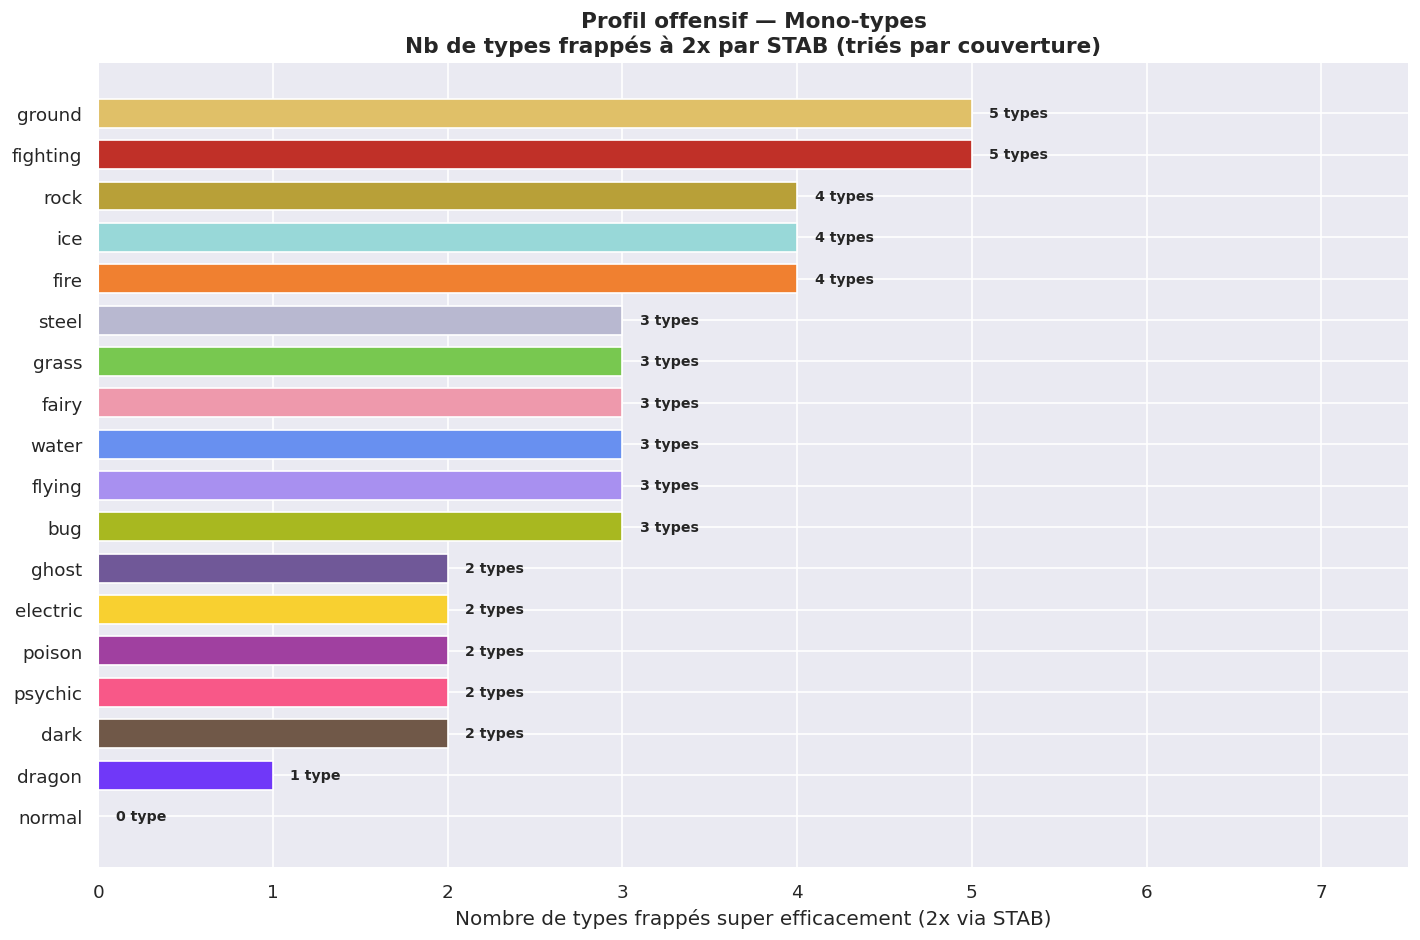

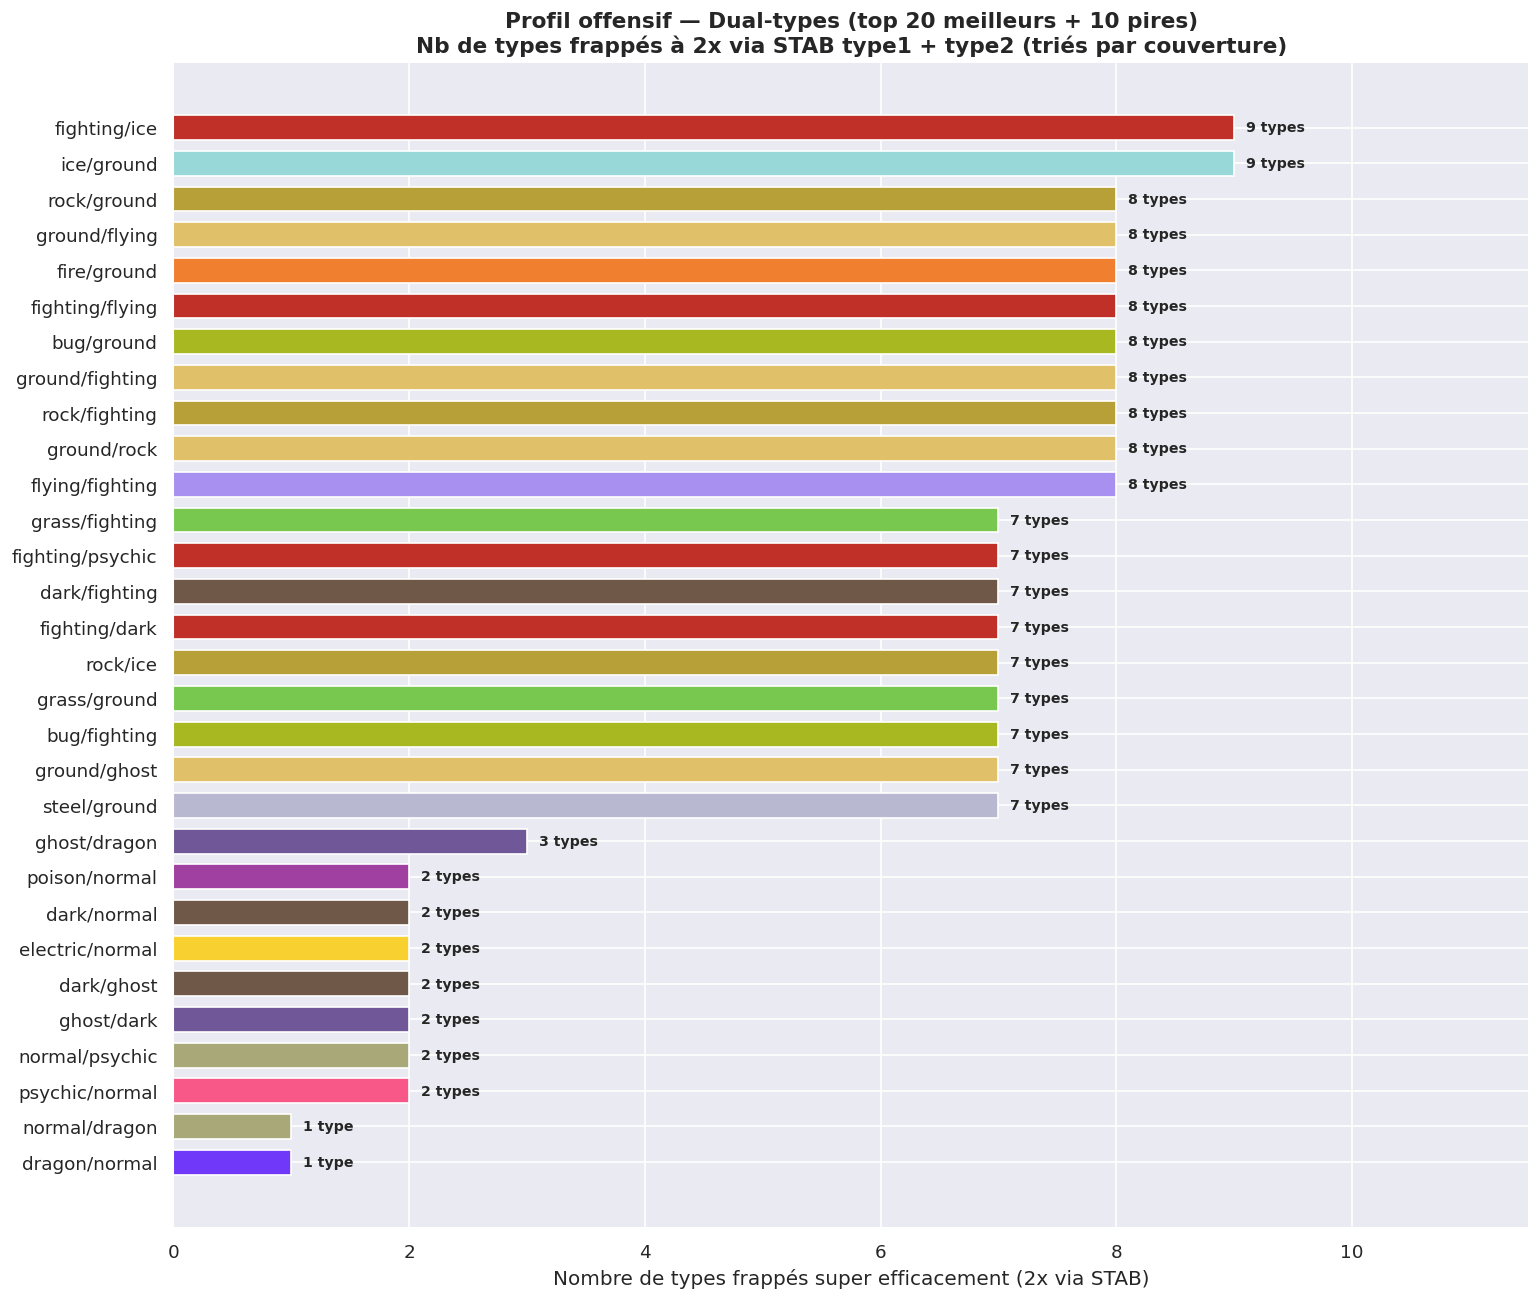


Top 10 meilleures combinaisons offensives


,label,n_offense,defense_score
0,ice/ground,9,-2
1,fighting/ice,9,-3
2,rock/ground,8,1
3,ground/rock,8,1
4,bug/ground,8,1
5,flying/fighting,8,1
6,ground/fighting,8,0
7,rock/fighting,8,-1
8,fighting/flying,8,1
9,fire/ground,8,4


In [99]:
mono_off = mono_df.sort_values('n_offense', ascending=True).reset_index(drop=True)
dual_off_sorted = combo_df[combo_df['is_dual']].sort_values('n_offense', ascending=False)
top_dual_off = pd.concat([dual_off_sorted.head(20), dual_off_sorted.tail(10)]).drop_duplicates(subset=['label']).sort_values('n_offense', ascending=True).reset_index(drop=True)

def offense_barh(ax, data, title):
    colors = [TYPE_COLORS.get(row['type1'], '#888') for _, row in data.iterrows()]
    bars = ax.barh(data['label'], data['n_offense'], color=colors, edgecolor='white', height=0.7)
    for bar, val in zip(bars, data['n_offense']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{int(val)} type{"s" if val > 1 else ""}', va='center', fontsize=8.5, fontweight='bold')
    ax.set_xlabel('Nombre de types frappés super efficacement (2x via STAB)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, max(data['n_offense']) + 2.5)

fig, ax = plt.subplots(figsize=(12, 8))
offense_barh(ax, mono_off,
    'Profil offensif — Mono-types\nNb de types frappés à 2x par STAB (triés par couverture)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 11))
offense_barh(ax, top_dual_off,
    'Profil offensif — Dual-types (top 20 meilleurs + 10 pires)\nNb de types frappés à 2x via STAB type1 + type2 (triés par couverture)')
plt.tight_layout()
plt.show()

print('\nTop 10 meilleures combinaisons offensives')
display(combo_df.sort_values('n_offense', ascending=False).head(10)[
    ['label','n_offense','defense_score']].reset_index(drop=True))


---
## 6. Construction d'équipe optimale multi-critères

### Critères de sélection
| Critère | Poids | Description |
|---|---|---|
| BST normalisé | 40% | Puissance brute globale |
| Score défensif (dual-type) | 25% | Résistances & immunités réelles |
| Couverture offensive STAB (type1+type2) | 20% | Nb de types frappés super efficacement |
| Équilibre des stats | 15% | Pokémon polyvalent vs trop spécialisé |

> L'algorithme greedy sélectionne les membres en couvrant les **faiblesses défensives** ET les **angles morts offensifs** de l'équipe.

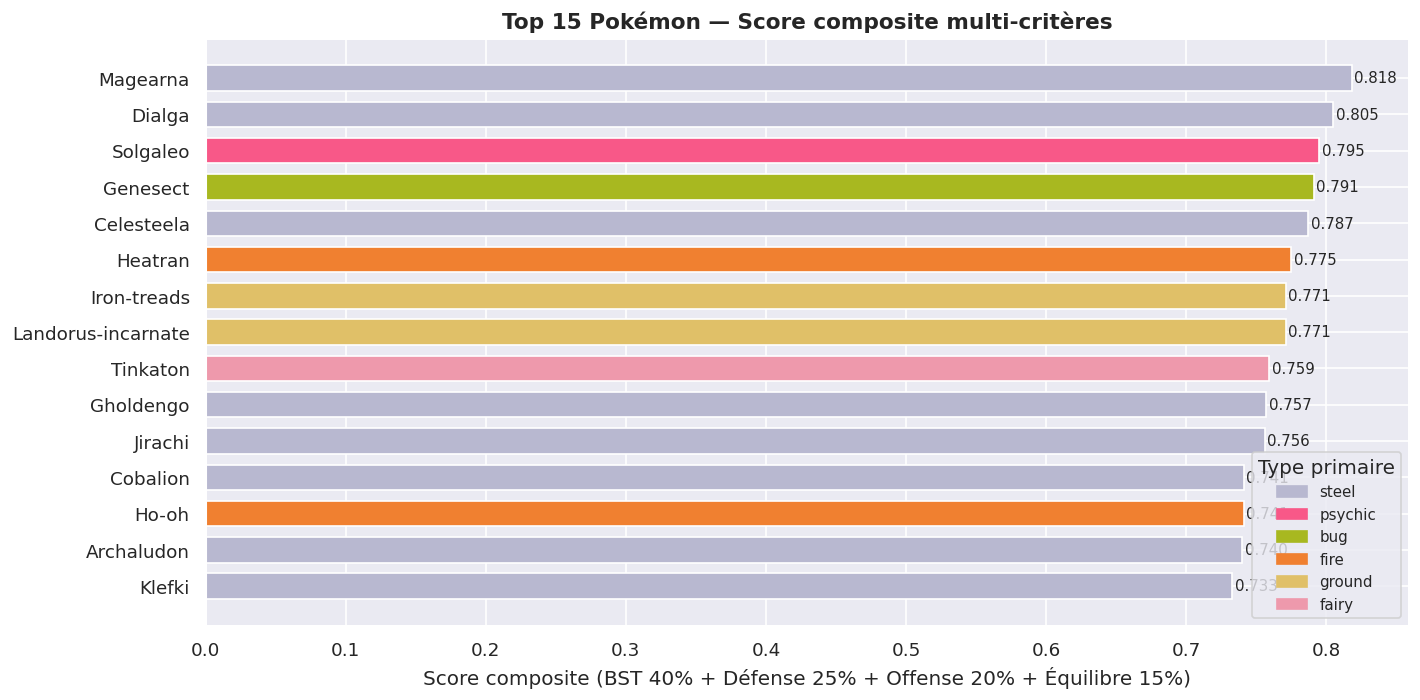

,name,type1,type2,bst,defense_score,n_offense,balance,composite
0,Magearna,steel,fairy,600,11,6,0.818,0.818
1,Dialga,steel,dragon,680,9,4,0.858,0.805
2,Solgaleo,psychic,steel,680,7,5,0.868,0.795
3,Genesect,bug,steel,600,9,6,0.863,0.791
4,Celesteela,steel,flying,570,10,6,0.867,0.787
5,Heatran,fire,steel,600,8,6,0.863,0.775
6,Iron-treads,ground,steel,570,8,7,0.835,0.771
7,Landorus-incarnate,ground,flying,600,5,8,0.872,0.771
8,Tinkaton,fairy,steel,506,11,6,0.884,0.759
9,Gholdengo,steel,ghost,550,11,5,0.808,0.757


In [100]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df['stat_std']  = df[STATS].std(axis=1)
df['stat_mean'] = df[STATS].mean(axis=1)
df['balance']   = 1 - normalize(df['stat_std'] / df['stat_mean'])

df['bst_norm']  = normalize(df['bst'])
df['def_norm']  = normalize(df['defense_score'])
df['off_norm']  = normalize(df['n_offense'])
df['composite'] = (0.40 * df['bst_norm']
                 + 0.25 * df['def_norm']
                 + 0.20 * df['off_norm']
                 + 0.15 * df['balance'])

top15 = df.nlargest(15, 'composite')[['name','type1','type2','bst','defense_score','n_offense','balance','composite']].copy()
top15['name'] = top15['name'].str.capitalize()
top15 = top15.round(3).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors_top = [TYPE_COLORS.get(t, '#888') for t in top15['type1']]
bars = ax.barh(top15['name'][::-1], top15['composite'][::-1], color=colors_top[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Score composite (BST 40% + Défense 25% + Offense 20% + Équilibre 15%)')
ax.set_title('Top 15 Pokémon — Score composite multi-critères', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15['composite'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
handles = [mpatches.Patch(color=TYPE_COLORS.get(t,'#888'), label=t) for t in top15['type1'].unique()]
ax.legend(handles=handles, title='Type primaire', loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()
display(top15)

In [101]:
def build_team(pool, size=6):
    team, team_def_profiles = [], []
    team_off_covered = set()

    first = pool.iloc[0]
    team.append(first)
    team_def_profiles.append(first['defense_profile'])
    team_off_covered.update(first['offense_coverage'])
    remaining = pool.iloc[1:].copy()

    while len(team) < size and len(remaining) > 0:
        team_weaknesses = {t for p in team_def_profiles for t, v in p.items() if v > 1}
        off_gaps = set(ALL_TYPES) - team_off_covered

        def candidate_score(row):
            def_cover = sum(1 for t in team_weaknesses if row['defense_profile'].get(t, 1) <= 1)
            off_cover = len(row['offense_coverage'] & off_gaps)
            return row['composite'] + 0.12 * def_cover + 0.08 * off_cover

        best_idx = remaining.apply(candidate_score, axis=1).idxmax()
        best = remaining.loc[best_idx]
        team.append(best)
        team_def_profiles.append(best['defense_profile'])
        team_off_covered.update(best['offense_coverage'])
        remaining = remaining.drop(best_idx)

    return pd.DataFrame(team)

pool    = df.nlargest(150, 'composite').reset_index(drop=True)
team_df = build_team(pool)

print('Équipe optimale multi-critères')
display(team_df[['name','type1','type2','bst','defense_score','n_offense','balance','composite']].assign(
    name=lambda d: d['name'].str.capitalize()
).round(3).reset_index(drop=True))

off_covered = set()
for cov in team_df['offense_coverage']:
    off_covered.update(cov)
print(f'\nCouverture offensive totale : {len(off_covered)}/18 types couverts à 2x')
not_covered = sorted(set(ALL_TYPES) - off_covered)
print(f'Types non couverts offensivement : {not_covered if not_covered else "Aucun !"}')

Équipe optimale multi-critères


,name,type1,type2,bst,defense_score,n_offense,balance,composite
0,Magearna,steel,fairy,600,11,6,0.818,0.818
1,Landorus-incarnate,ground,flying,600,5,8,0.872,0.771
2,Marshadow,fighting,ghost,600,3,7,0.853,0.712
3,Tapu-fini,water,fairy,570,5,6,0.816,0.696
4,Zapdos,electric,flying,580,5,5,0.887,0.691
5,Dialga,steel,dragon,680,9,4,0.858,0.805



Couverture offensive totale : 18/18 types couverts à 2x
Types non couverts offensivement : Aucun !


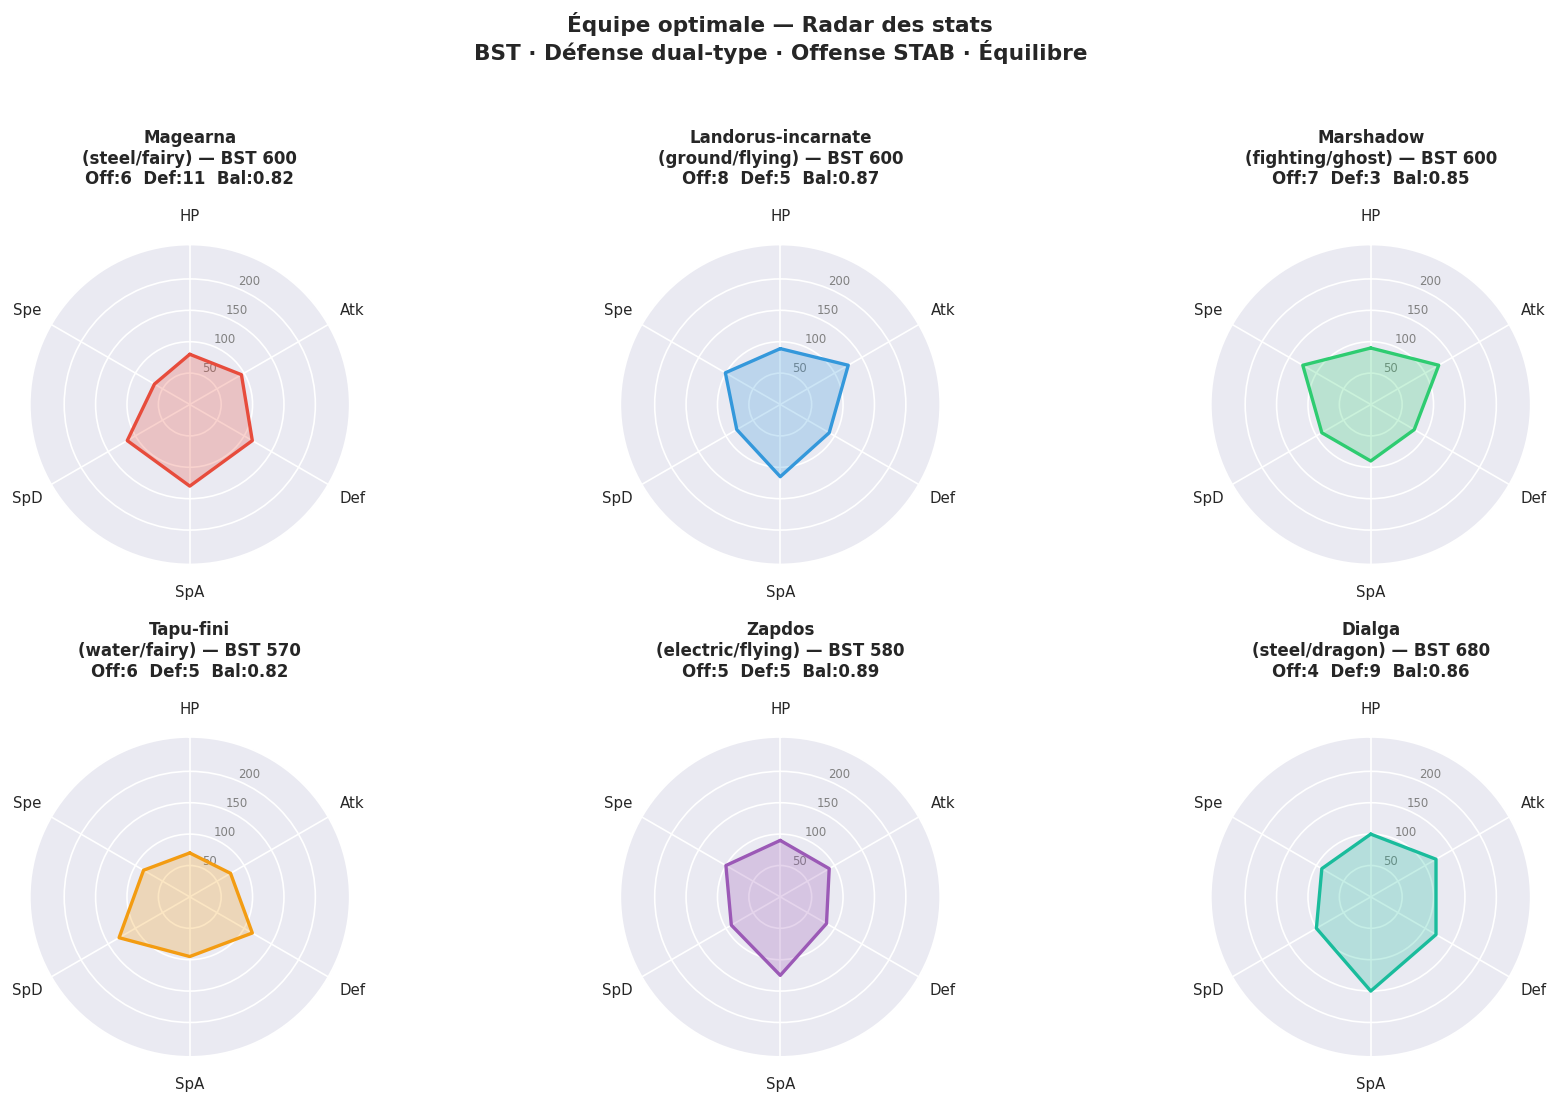

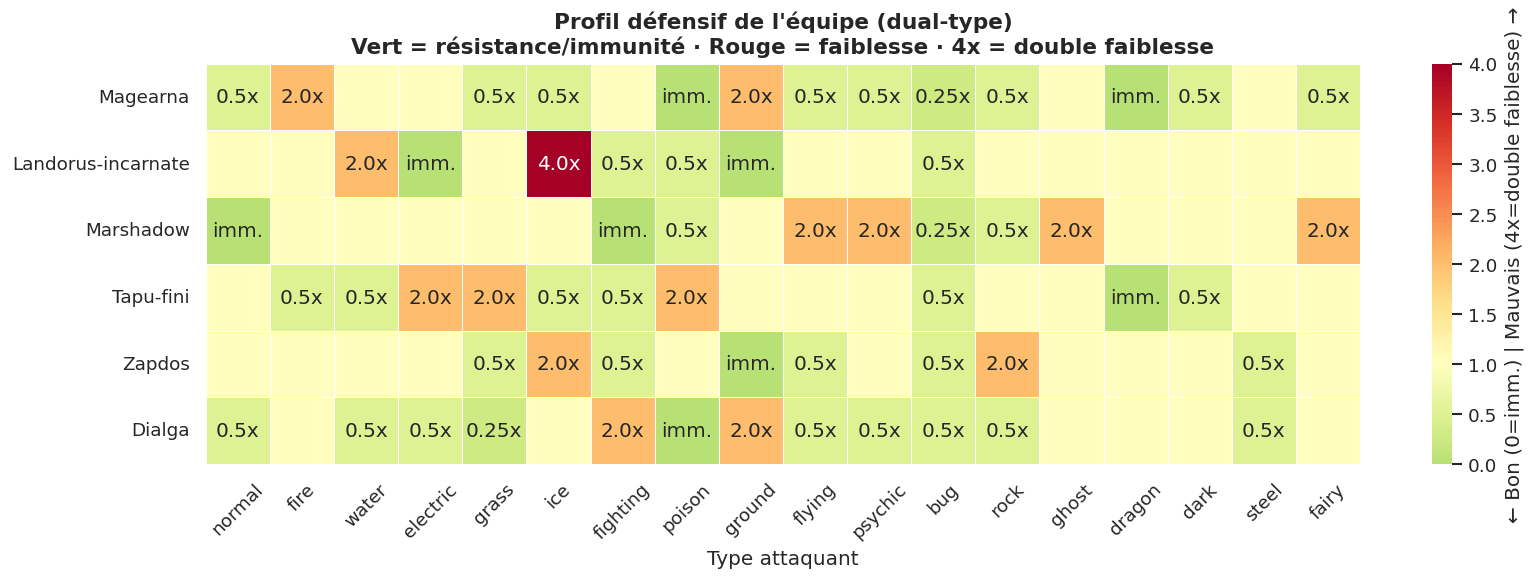

In [102]:
def radar_chart(ax, values, labels, color, title, max_val=255):
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)] + [0]
    vals   = list(values) + [values[0]]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, max_val)
    ax.set_yticks([50, 100, 150, 200])
    ax.set_yticklabels(['50','100','150','200'], size=7, color='grey')
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_title(title, size=10, fontweight='bold', pad=15)

radar_labels = ['HP', 'Atk', 'Def', 'SpA', 'SpD', 'Spe']
fig, axes = plt.subplots(2, 3, figsize=(15, 9), subplot_kw=dict(polar=True))
axes = axes.flatten()
team_colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

for ax, (_, row), color in zip(axes, team_df.iterrows(), team_colors):
    vals = [row[s] for s in STATS]
    type_info = row['type1'] if pd.isna(row['type2']) else f"{row['type1']}/{row['type2']}"
    info = f"Off:{int(row['n_offense'])}  Def:{int(row['defense_score'])}  Bal:{row['balance']:.2f}"
    radar_chart(ax, vals, radar_labels, color,
                f"{row['name'].capitalize()}\n({type_info}) — BST {int(row['bst'])}\n{info}")

plt.suptitle('Équipe optimale — Radar des stats\nBST · Défense dual-type · Offense STAB · Équilibre',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
team_weak = pd.DataFrame(
    [row['defense_profile'] for _, row in team_df.iterrows()],
    index=[row['name'].capitalize() for _, row in team_df.iterrows()]
)
annot_w = team_weak.map(lambda v: '' if v == 1 else ('imm.' if v == 0 else f'{v}x'))
sns.heatmap(team_weak, annot=annot_w, fmt='', cmap='RdYlGn_r', center=1, vmin=0, vmax=4,
            linewidths=0.4, ax=ax, cbar_kws={'label': '← Bon (0=imm.) | Mauvais (4x=double faiblesse) →'})
ax.set_title("Profil défensif de l'équipe (dual-type)\nVert = résistance/immunité · Rouge = faiblesse · 4x = double faiblesse",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Type attaquant')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()